# Flight Price Prediction

## Problem Statement
Flight ticket prices are highly dynamic and unpredictable. This project aims to predict flight prices using machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_excel(r"D:\projects\flight fare prediction\Flight_Fare.xlsx")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


## Data Understanding

In [3]:
df.shape

(10683, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [8]:
df.dropna(inplace=True)

## Data Preprocessing

In [9]:
df["Date_of_Journey"]=pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y")

df["journey_day"]=df["Date_of_Journey"].dt.day
df["journey_month"]=df["Date_of_Journey"].dt.month

In [10]:
df.drop('Date_of_Journey', axis=1, inplace=True)

In [11]:
df["Dep_Time"]= pd.to_datetime(df["Dep_Time"], format="%H:%M")

df["dep_hour"]=df["Dep_Time"].dt.hour
df["dep_minutes"]=df["Dep_Time"].dt.minute

In [12]:
df.drop('Dep_Time',axis=1, inplace=True)

In [13]:
df["Arrival_Time"]=pd.to_datetime(df["Arrival_Time"], format="mixed")

df["Arrival_hour"]=df["Arrival_Time"].dt.hour
df["Arrival_minute"]=df["Arrival_Time"].dt.minute

In [14]:
df.drop("Arrival_Time", axis=1, inplace=True)

In [15]:
duration= list(df["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

In [16]:
duration_hours = []
duration_mins = []

In [17]:
for i in range(len(duration)):

    duration_hours.append(int(duration[i].split()[0][:-1]))
    duration_mins.append(int(duration[i].split()[1][:-1]))

In [18]:
df["duration_hour"]= duration_hours
df["duration_mins"]= duration_mins

In [19]:
df.drop('Duration', axis=1, inplace=True)

In [20]:
df["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [21]:
df["Total_Stops"]=df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [22]:
df.drop(["Route", "Additional_Info"], axis=1, inplace=True)

## Exploratory Data Analysis

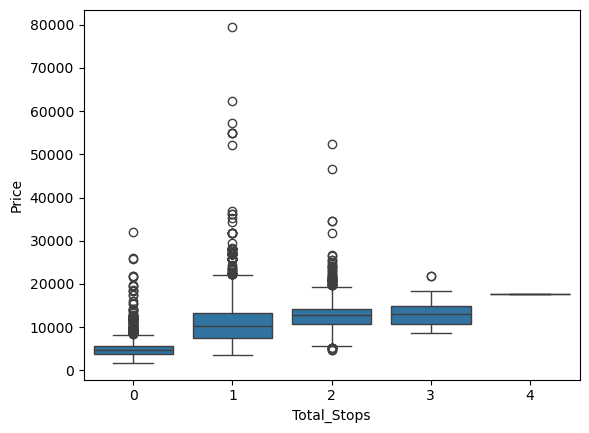

In [23]:
sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.show()

In [24]:
plt.figure(figsize=(10,5))
sns.set()

<Figure size 1000x500 with 0 Axes>

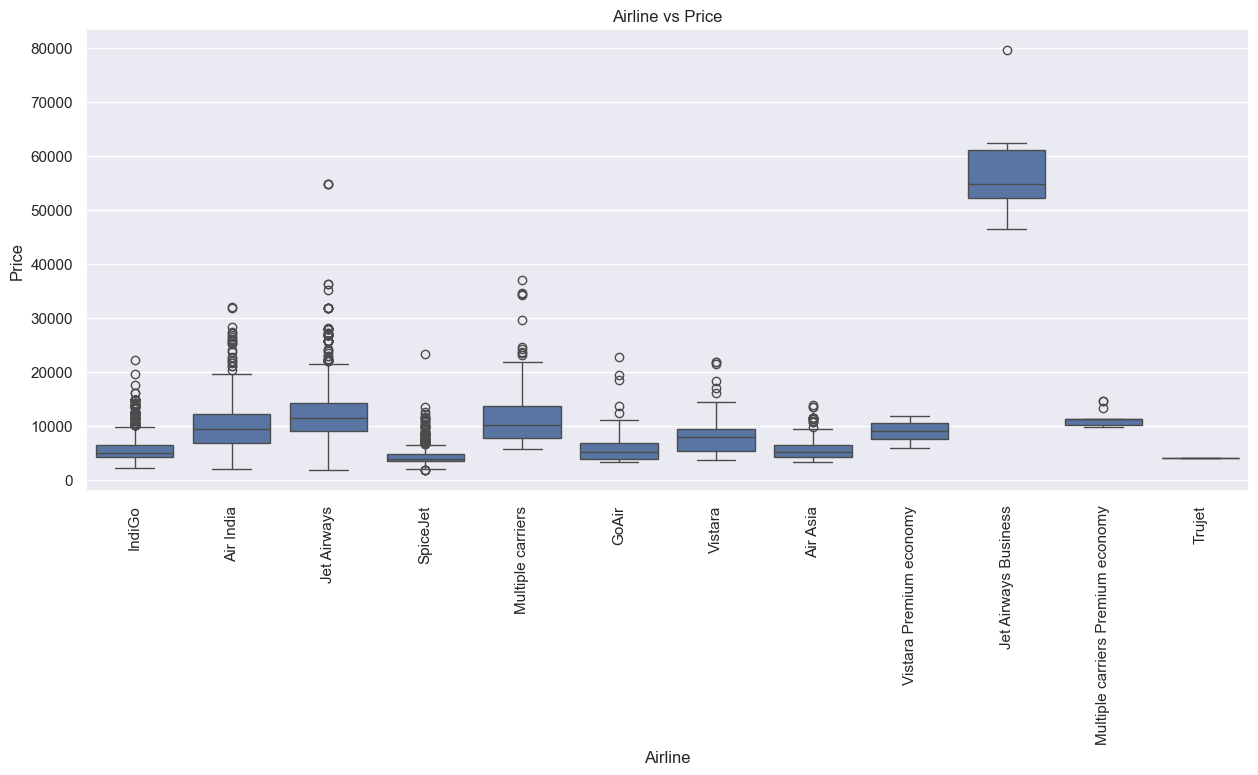

In [25]:
plt.figure(figsize=(15,6))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

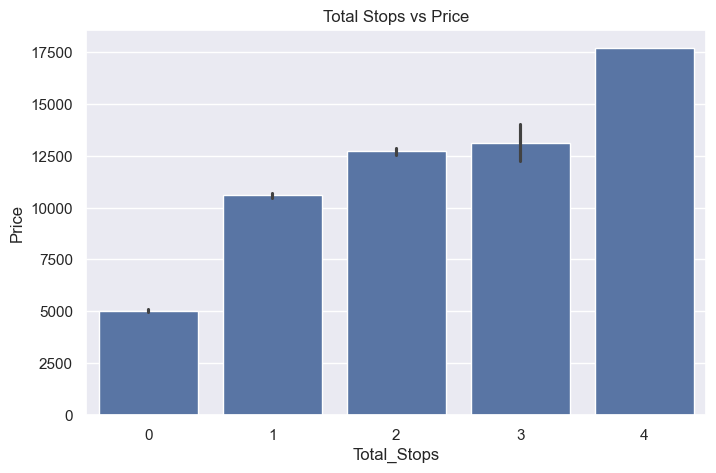

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x="Total_Stops", y="Price", data=df)
plt.title("Total Stops vs Price")
plt.show()

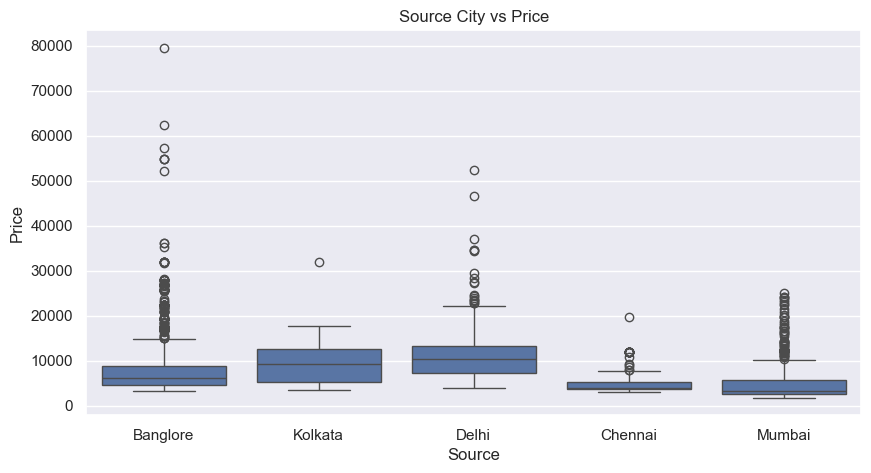

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Source", y="Price", data=df)
plt.title("Source City vs Price")
plt.show()

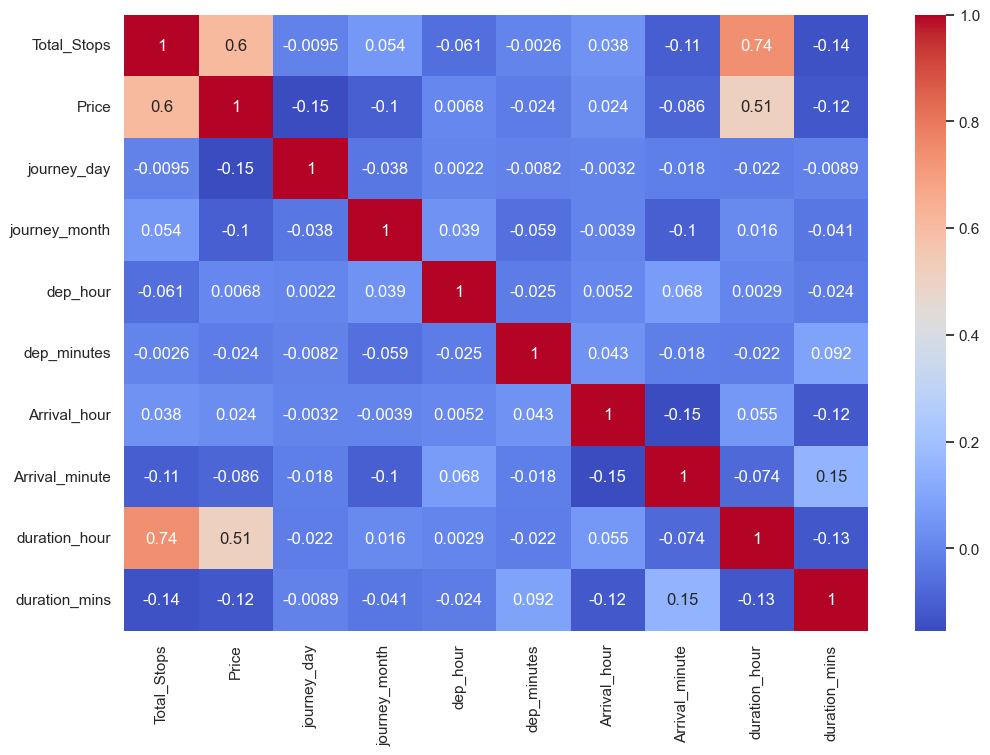

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=True
)

plt.show()

## Categorical Encoding

In [29]:
df=pd.get_dummies(df, columns=["Airline","Source","Destination"], drop_first=True)

## Train Test Split

In [30]:
x = df.drop("Price", axis=1)
y = df["Price"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

## Model Building

## LinearRegression

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## prediction

In [32]:
y_pred_lr = lr.predict(x_test)

## Model Evaluation

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_lr)))
print("MAE_lr:", mean_absolute_error(y_test, y_pred_lr))
print("r2_score:", r2_score(y_test, y_pred_lr))

RMSE: 44.41775867279668
MAE_lr: 1972.9372855148047
r2_score: 0.6195943729070101


## Decision Tree 

In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Prediction

In [35]:
y_pred_dt=dt.predict(x_test)

## Model Evaluation 

In [36]:
print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_dt)))
print("MAE_dt;", mean_absolute_error(y_test,y_pred_dt))
print("r2_score", r2_score(y_test,y_pred_dt))

RMSE: 36.55662665117714
MAE_dt; 1336.386952113555
r2_score 0.7245034671592279


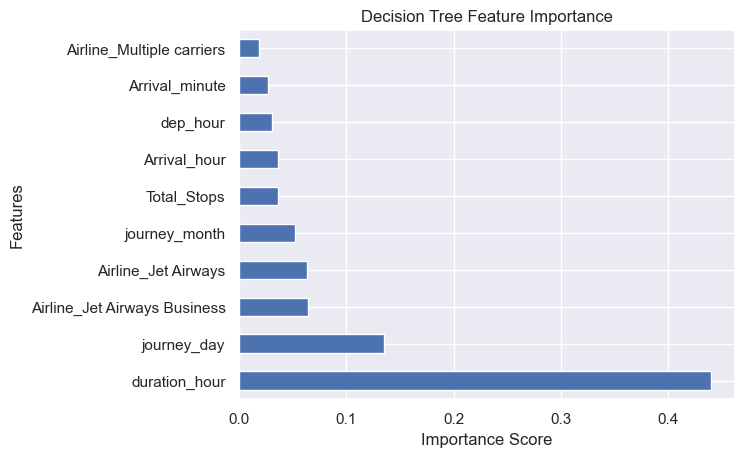

In [37]:
feat_importance = pd.Series(
    dt.feature_importances_,
    index=x.columns
)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Random Forest

In [38]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
print("Train Score:", model.score(x_train, y_train))
print("Test Score:", model.score(x_test, y_test))

Train Score: 0.9534420683785766
Test Score: 0.7975388505283276


## Prediction

In [40]:
y_pred_rf=model.predict(x_test)

## Model Evaluation

In [41]:
print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("r2_score:", r2_score(y_test, y_pred_rf))

RMSE: 34.29530452745537
MAE: 1176.1679126309011
r2_score: 0.7975388505283276


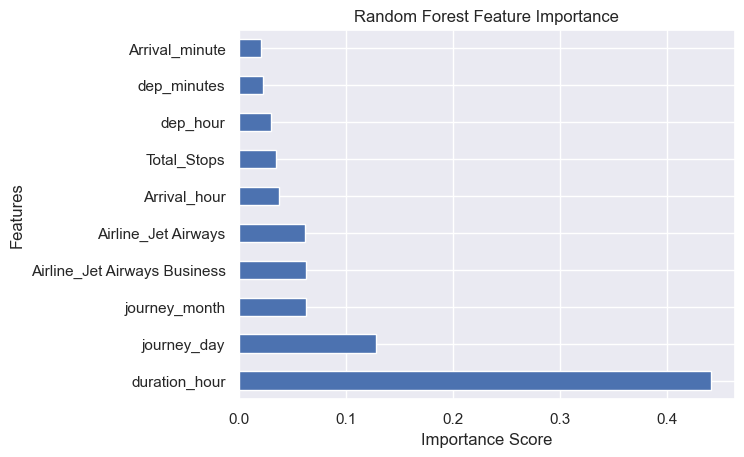

In [42]:
feat_importance = pd.Series(
    model.feature_importances_,
    index=x.columns
)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Gradient Boosting

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gbr=GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gbr.fit(x_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Prediction

In [45]:
y_pred_gbr=gbr.predict(x_test)

## Model Evaluation

In [46]:
print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_gbr)))
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("r2_score:", r2_score(y_test, y_pred_gbr))

RMSE: 39.086606156880556
MAE: 1527.762780863093
r2_score: 0.7856246475690609


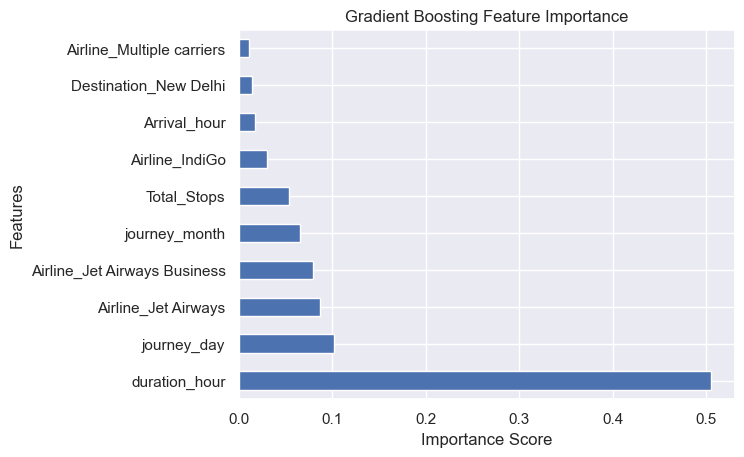

In [47]:
feat_importance = pd.Series(
    gbr.feature_importances_,
    index=x.columns
)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## XGBoost

In [48]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Prediction

In [49]:
y_pred_xgb = xgb.predict(x_test)

## Model Evaluation

In [50]:
print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test,y_pred_xgb))
print("r2_score:", r2_score(y_test,y_pred_xgb))

RMSE: 35.25835173668077
MAE: 1243.1513671875
r2_score: 0.8392704725265503


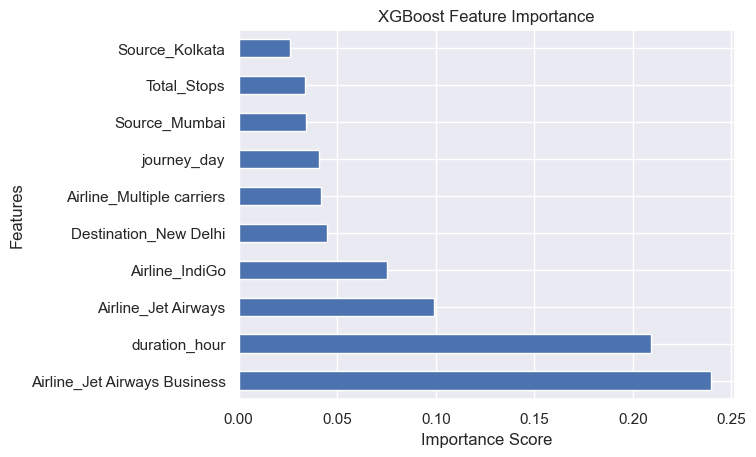

In [51]:
feat_importance = pd.Series(
    xgb.feature_importances_,
    index=x.columns
)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## XGBoost Tuned

In [52]:
xgb_tuned = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_tuned.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Prediction

In [53]:
y_pred_xgb_tuned=xgb_tuned.predict(x_test)

## Model Evaluation

In [54]:
print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_xgb_tuned)))
print("MAE:", mean_absolute_error(y_test,y_pred_xgb_tuned))
print("r2_score:", r2_score(y_test,y_pred_xgb_tuned))

RMSE: 33.76509898074767
MAE: 1140.0819091796875
r2_score: 0.8579936623573303


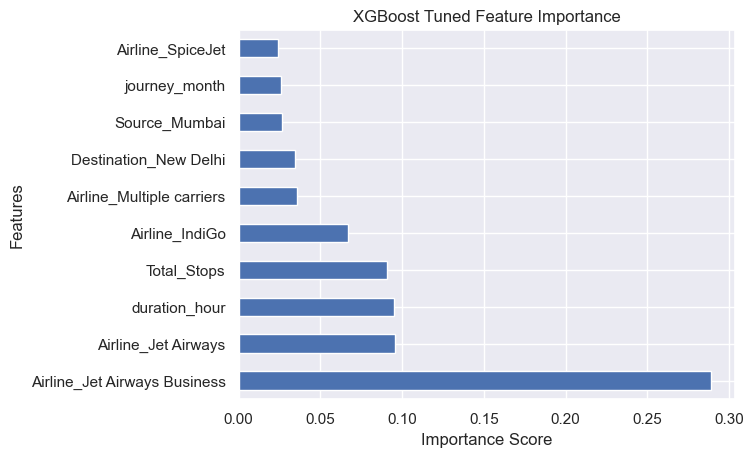

In [55]:
feat_importance = pd.Series(
    xgb_tuned.feature_importances_,
    index=x.columns
)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("XGBoost Tuned Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Model Comparison Report

| Model | RMSE | MAE | R² Score | Remarks |
|---|---|---|---|---|
| Linear Regression | 44.42 | 1972.94 | 0.6196 | Underfitting, low accuracy |
| Decision Tree | 36.67 | 1345.03 | 0.7220 | Better than Linear Regression but slightly overfitting |
| Random Forest | 34.30 | 1176.17 | 0.7975 | Good performance with better generalization |
| Gradient Boosting | 39.09 | 1527.76 | 0.7856 | Better than basic models but less accurate than ensemble boosting models |
| XGBoost (Default) | 35.26 | 1243.15 | 0.8393 | Strong predictive performance |
| XGBoost (Tuned) | 33.77 | 1140.08 | 0.8580 | Best overall model with highest accuracy |

---

## Final Model Selection

The tuned XGBoost model achieved the:

- Highest R² Score → **0.8580**
- Lowest RMSE → **33.77**
- Lowest MAE → **1140.08**

This indicates that the tuned XGBoost model provides the best predictive performance among all models tested.

Hence, the **Tuned XGBoost Regressor** is selected as the final model for Flight Price Prediction.

In [56]:
import pickle

with open("flight_price_model.pkl", "wb") as f:
    pickle.dump(xgb_tuned, f)

In [57]:
sample= x_test.iloc[0:1]
prediction= model.predict(sample)
print("predict_price:", prediction)

predict_price: [16872.55]


## Conclusion

Random Forest Regressor gave the best performance
with highest R2 Score and lowest MAE.

Hence Random Forest is selected as the final model
for Flight Price Prediction.